##**Model to predict if a customer will subscribe to a term deposit or not**




In [ ]:
#import warnings

#warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split, GridSearchCV


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    RandomForestClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV
import pprint

##Loading the data

In [ ]:
# mount Google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Model evaluation criteria

**Model can make wrong predictions as:**
- Customer is predicted to subscribe but in reality does not
- Customer is predicted not to subscribe but in reality does

** Which case is more important**
Both:
- If a customer is prediced to subscribe but does not, marketing efforts are wasted on them.
- If a customer is predicted not to subscribe but does, a potential customer could have been missed.

**How to reduce losses**
- FI score is a better balanced metic especially since the classes are inbalanced.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Models

We will tune Logistic Regression, KNeighborsClassifier, Decision Tree Classifier , Random Forest Classifier and XGBClassifier

In [ ]:
models = [
    (LogisticRegression, {'max_iter': [1000, 1500, 2000]}),
    (KNeighborsClassifier, {'n_neighbors': np.arange(2, 10, 1)}),
    (DecisionTreeClassifier, {'max_depth': np.arange(5, 10, 1)}),
    (RandomForestClassifier, {'n_estimators': np.arange(5, 10, 1)}),
    (XGBClassifier, {'n_estimators': [100, 150, 200], 'subsample': [0.8, 0.9, 1]})
]

In [ ]:
X_train_full = pd.read_csv('undersampled_scaled_train.csv')
y_train = X_train_full['y']
X_train = X_train_full.drop('y', axis=1)

In [ ]:
X_train.head()

,age,default,balance,housing,loan,day,duration,campaign,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,-1.188951,-0.136356,-0.268337,0.889622,2.396961,-0.226759,-0.693439,0.129525,-0.373369,-0.508542,-0.190522,-0.138221,-0.525401,-0.214927,-0.201381,-0.320670,6.674621,-0.450915,-0.173901,-0.073867,-0.37551,0.866275,-0.662661,-0.3941,0.977558,-0.685885,-0.188426,0.673861,-0.250851,-0.582098,-0.345804,-0.351588,-0.022217,-0.269234,-0.147219,-0.419637,-0.358197,-0.149821,1.479735,-0.304987,-0.099825
1,0.071258,-0.136356,-0.348724,0.889622,-0.417195,0.364343,-0.863553,-0.603337,-0.373369,-0.508542,-0.190522,-0.138221,-0.525401,-0.214927,-0.201381,-0.320670,-0.149821,2.217712,-0.173901,-0.073867,-0.37551,0.866275,-0.662661,-0.3941,0.977558,-0.685885,-0.188426,-1.483985,-0.250851,1.717925,-0.345804,-0.351588,-0.022217,-0.269234,-0.147219,-0.419637,-0.358197,-0.149821,1.479735,-0.304987,-0.099825
2,0.846771,-0.136356,-0.433048,0.889622,-0.417195,0.127902,0.489961,-0.236906,-0.373369,-0.508542,-0.190522,-0.138221,-0.525401,-0.214927,-0.201381,3.118472,-0.149821,-0.450915,-0.173901,-0.073867,-0.37551,0.866275,-0.662661,-0.3941,0.977558,-0.685885,-0.188426,0.673861,-0.250851,-0.582098,-0.345804,-0.351588,-0.022217,-0.269234,-0.147219,-0.419637,-0.358197,-0.149821,-0.675797,3.278830,-0.099825
3,-0.025681,-0.136356,-0.089845,-1.124073,-0.417195,-0.581421,2.065363,-0.236906,2.678318,-0.508542,-0.190522,-0.138221,-0.525401,-0.214927,-0.201381,-0.320670,-0.149821,-0.450915,-0.173901,-0.073867,-0.37551,-1.154368,1.509067,-0.3941,-1.022957,1.457969,-0.188426,-1.483985,-0.250851,1.717925,-0.345804,-0.351588,-0.022217,-0.269234,-0.147219,-0.419637,2.791760,-0.149821,-0.675797,-0.304987,-0.099825
4,0.459014,-0.136356,-0.375629,0.889622,-0.417195,0.364343,0.943598,0.129525,-0.373369,-0.508542,-0.190522,-0.138221,-0.525401,-0.214927,-0.201381,-0.320670,-0.149821,2.217712,-0.173901,-0.073867,-0.37551,0.866275,-0.662661,-0.3941,-1.022957,1.457969,-0.188426,-1.483985,-0.250851,1.717925,-0.345804,-0.351588,-0.022217,-0.269234,-0.147219,-0.419637,2.791760,-0.149821,-0.675797,-0.304987,-0.099825


In [ ]:
X_train.shape

(4054, 41)

In [ ]:
X_test_full = pd.read_csv('undersampled_scaled_test.csv')
y_test = X_test_full['y']
X_test = X_test_full.drop('y', axis=1)

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

def create_prediction_model(X_train, X_test, y_train, y_test, models):
    # TODO: Add "pipeline"
    results = []
    for model, params in models:
        print('🟡 START: ' + model.__name__)
        cv = GridSearchCV(model(), param_grid=params, cv=5)
        cv.fit(X_train, y_train)

        y_pred = cv.predict(X_test)
        y_pred_proba = cv.predict_proba(X_test)[:, 1] # Get probabilities for PR-AUC

        # Metrics
        f1 = f1_score(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred)

        # Calculate PR-AUC
        p, r, _ = precision_recall_curve(y_test, y_pred_proba)
        pr_auc = auc(r, p)

        best_params = cv.best_params_
        best_score = cv.best_score_

        print('🟢 END: ' + model.__name__)
        results.append({
            'model': {
                'instance': cv,
                'name': model.__name__
            },
            'metrics': {
                'f1': f1,
                'accuracy': accuracy,
                'recall': recall,
                'precision': precision,
                'roc_auc': roc_auc,
                'pr_auc': pr_auc, # Added PR-AUC
                'best_params': best_params,
                'best_score': best_score,
                'confusion_matrix': confusion_matrix(y_test, y_pred)
            }
        })

    return results

In [ ]:
results = create_prediction_model(
    X_train,
    X_test,
    y_train,
    y_test,
    models
)

pp = pprint.PrettyPrinter(indent=4)
pp.pprint(results)

🟡 START: LogisticRegression
🟢 END: LogisticRegression
🟡 START: KNeighborsClassifier
🟢 END: KNeighborsClassifier
🟡 START: DecisionTreeClassifier
🟢 END: DecisionTreeClassifier
🟡 START: RandomForestClassifier
🟢 END: RandomForestClassifier
🟡 START: XGBClassifier
🟢 END: XGBClassifier
[   {   'metrics': {   'accuracy': 0.8676639815880323,
                       'best_params': {'max_iter': 1000},
                       'best_score': np.float64(0.8623592272914099),
                       'confusion_matrix': array([[768, 123],
       [107, 740]]),
                       'f1': 0.8654970760233918,
                       'pr_auc': np.float64(0.910935831886024),
                       'precision': 0.8574739281575898,
                       'recall': 0.8736717827626919,
                       'roc_auc': np.float64(0.8678123223577768)},
        'model': {   'instance': GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'max_iter': [1000, 1500, 2000]}),
                     'n

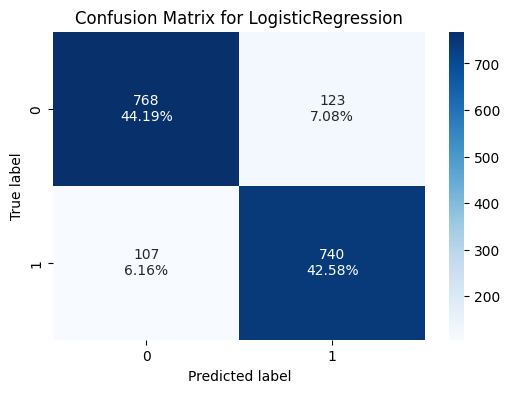

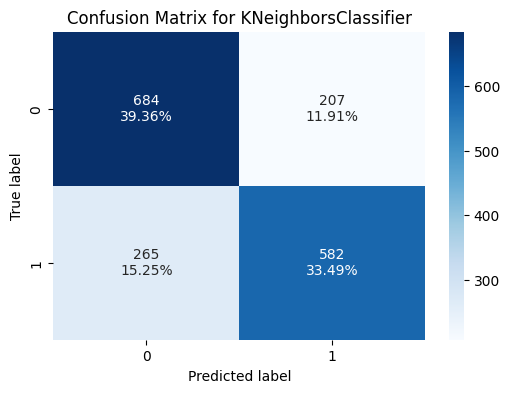

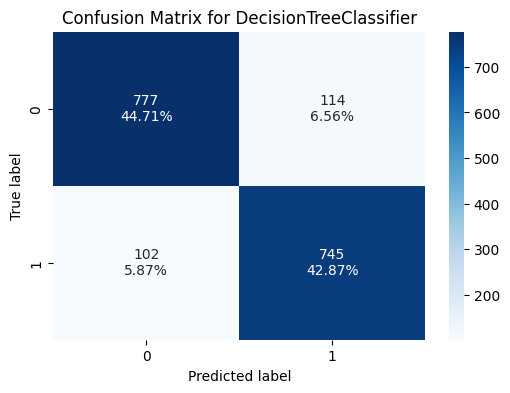

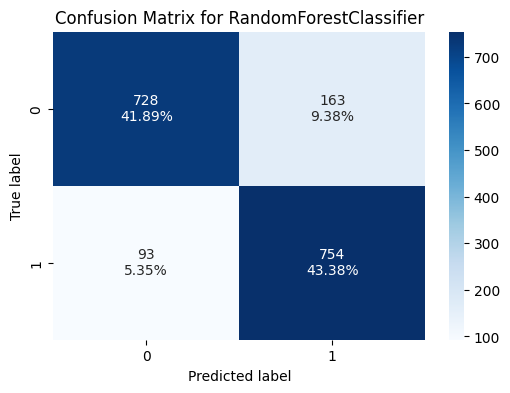

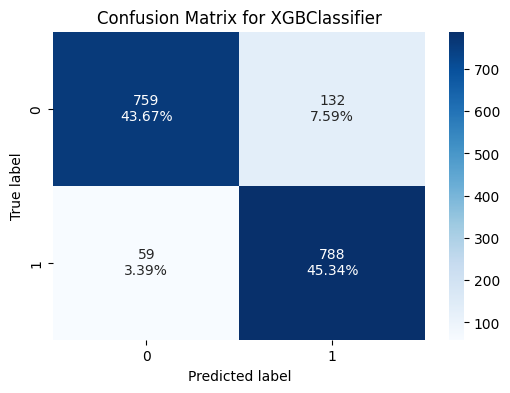

In [ ]:
def plot_confusion_matrix_from_array(conf_matrix, title):
    labels = np.asarray(
        [
            f"{item:0.0f}\n{item / conf_matrix.flatten().sum():.2%}"
            for item in conf_matrix.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Blues")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title(title)
    plt.show()

for model_result in results:
    model_name = model_result['model']['name']
    conf_matrix = model_result['metrics']['confusion_matrix']
    plot_confusion_matrix_from_array(conf_matrix, f"Confusion Matrix for {model_name}")

In [ ]:
model_summary_data = []

for model_result in results:
    model_name = model_result['model']['name']
    metrics = model_result['metrics']

    model_summary_data.append({
        'Model': model_name,
        'Accuracy (Test)': metrics['accuracy'],
        'Recall (Test)': metrics['recall'],
        'Precision (Test)': metrics['precision'],
        'F1-Score (Test)': metrics['f1'],
        'ROC-AUC (Test)': metrics['roc_auc'],
        'PR-AUC (Test)': metrics['pr_auc'],
        'Best CV Score (Train)': metrics['best_score'],
        'Best Params': str(metrics['best_params']) # Convert dict to string for display
    })

performance_summary_df = pd.DataFrame(model_summary_data)
display(performance_summary_df.round(4))

,Model,Accuracy (Test),Recall (Test),Precision (Test),F1-Score (Test),ROC-AUC (Test),PR-AUC (Test),Best CV Score (Train),Best Params
0,LogisticRegression,0.8677,0.8737,0.8575,0.8655,0.8678,0.9109,0.8624,{'max_iter': 1000}
1,KNeighborsClassifier,0.7284,0.6871,0.7376,0.7115,0.7274,0.7979,0.7235,{'n_neighbors': np.int64(9)}
2,DecisionTreeClassifier,0.8757,0.8796,0.8673,0.8734,0.8758,0.8863,0.8537,{'max_depth': np.int64(7)}
3,RandomForestClassifier,0.8527,0.8902,0.8222,0.8549,0.8536,0.8827,0.8550,{'n_estimators': np.int64(9)}
4,XGBClassifier,0.8901,0.9303,0.8565,0.8919,0.8911,0.9188,0.8794,"{'n_estimators': 200, 'subsample': 1}"


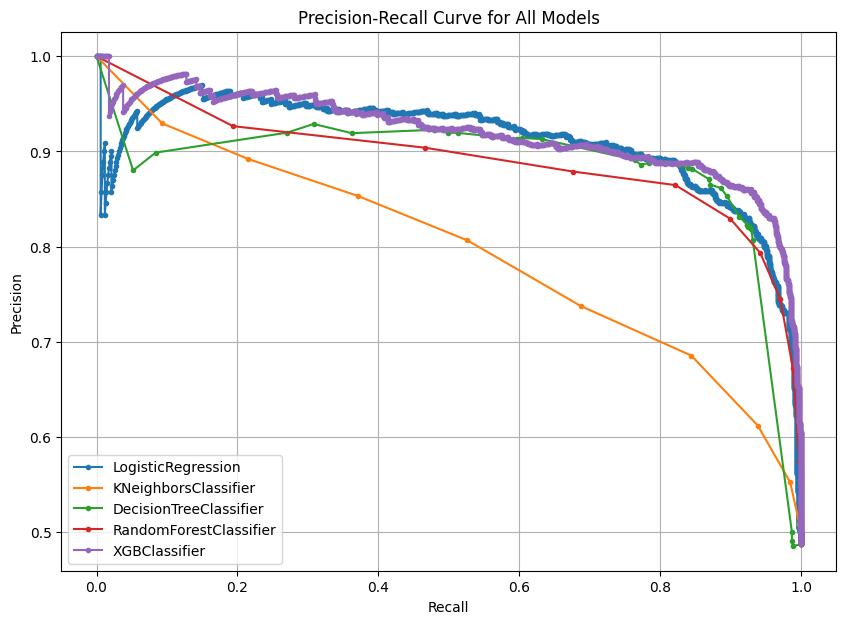

In [ ]:
plt.figure(figsize=(10, 7))

for model_result in results:
    model_name = model_result['model']['name']
    model_instance = model_result['model']['instance']

    # Get probabilities for the positive class on the test set
    y_pred_proba = model_instance.predict_proba(X_test)[:, 1]

    # Calculate precision, recall, and thresholds
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

    # Plot the Precision-Recall curve
    plt.plot(recall, precision, marker='.', label=model_name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for All Models')
plt.grid(True)
plt.legend()
plt.show()

**The Precision-Recall (PR)** curve illustrates the trade-off between Precision and Recall for different classification thresholds. It's particularly useful for evaluating models on imbalanced datasets, like predicting customer subscription where subscribers are likely the minority class. A model that maintains high precision as recall increases is generally considered better.

From the plot, we can interpret the following:

**Higher Curve = Better Performance:** A curve closer to the top-right corner indicates a better model. This means the model achieves higher precision for a given level of recall, or higher recall for a given level of precision.

**XGBoostClassifier and RandomForestClassifier:** These models appear to have the highest Precision-Recall curves. This suggests they are performing the best, achieving a good balance between correctly identifying subscribers (high recall) and avoiding false positives (high precision).

**LogisticRegression:** This model also shows a reasonably strong curve, indicating solid performance. It often serves as a good baseline.

**DecisionTreeClassifier and KNeighborsClassifier:** These models exhibit lower PR curves compared to the others. This implies they are struggling more with the precision-recall trade-off, either by having lower precision at similar recall levels or by seeing a more rapid drop in precision as recall increases.

In the context of predicting customer subscriptions, a model with a higher PR curve is desirable because it means we can identify a larger proportion of potential subscribers without making too many erroneous predictions (wasting marketing efforts), or vice versa.

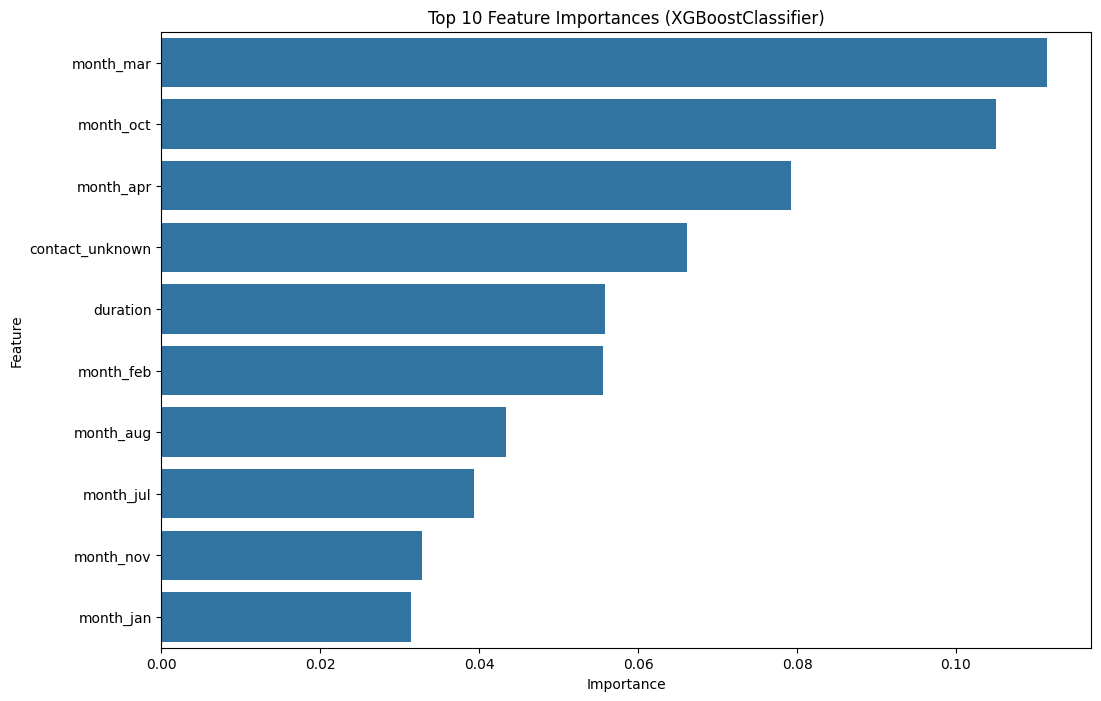

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Find the XGBoostClassifier model instance
xgb_model_instance = None
for model_result in results:
    if model_result['model']['name'] == 'XGBClassifier':
        xgb_model_instance = model_result['model']['instance']
        break

if xgb_model_instance:
    # Get the best estimator from the GridSearchCV object
    best_xgb_estimator = xgb_model_instance.best_estimator_

    # Get feature importances
    feature_importances = best_xgb_estimator.feature_importances_

    # Get feature names from X_train
    feature_names = X_train.columns

    # Create a DataFrame for better visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # Sort by importance in descending order
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Plot the top 10 features
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
    plt.title('Top 10 Feature Importances (XGBoostClassifier)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print("XGBoostClassifier not found in results.")

**Overall Impact:**

The analysis confirms that the **timing of contact (month)** and **the duration of the call** are the most critical factors determining customer subscription. Financial indicators like housing loan status also play a notable role. This information is vital for optimizing future marketing strategies, as efforts can be concentrated during high-performing months, and sales teams can be trained to maximize the effectiveness of customer interactions, while also considering key demographic factors.

##Predict final test set results using the optimal threshold

In [ ]:
# Define a range of thresholds to evaluate
thresholds = np.arange(0.1, 0.9, 0.01)

f1_scores = []
precision_scores = []
recall_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_threshold))
    precision_scores.append(precision_score(y_test, y_pred_threshold))
    recall_scores.append(recall_score(y_test, y_pred_threshold))

# Find the threshold that maximizes the F1-score
optimal_threshold_index = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal threshold (maximizing F1-score): {optimal_threshold:.4f}")
print(f"Corresponding F1-score: {f1_scores[optimal_threshold_index]:.4f}")
print(f"Corresponding Precision: {precision_scores[optimal_threshold_index]:.4f}")
print(f"Corresponding Recall: {recall_scores[optimal_threshold_index]:.4f}")

Optimal threshold (maximizing F1-score): 0.5200
Corresponding F1-score: 0.8927
Corresponding Precision: 0.8600
Corresponding Recall: 0.9280


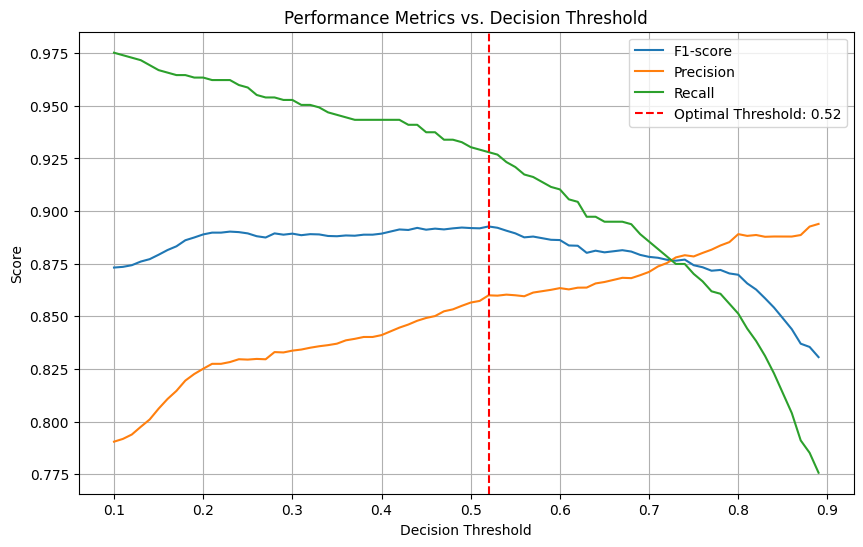

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Performance Metrics vs. Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()

Recall generally decreases: It becomes harder for a prediction to be classified as positive, so fewer true positives are captured.
Precision generally increases (then might decrease): When only very confident predictions are classified as positive, those positive predictions are more likely to be correct. However, if the threshold gets too high, you might only pick out a very small, unrepresentative subset of positive cases, potentially making precision less stable.
F1-score often peaks: There's usually a sweet spot where the balance between precision and recall is optimal, and that's where the F1-score is highest.

In [ ]:
# Define the default threshold (common for binary classification)
default_threshold = 0.5

# Get predicted labels for the default threshold
y_pred_default = (y_pred_proba >= default_threshold).astype(int)

# Calculate performance metrics for the default threshold
accuracy_default = accuracy_score(y_test, y_pred_default)
precision_default = precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)

print(f"--- Model Performance with Default Threshold ({default_threshold:.1f}) ---")
print(f"Accuracy:  {accuracy_default:.4f}")
print(f"Precision: {precision_default:.4f}")
print(f"Recall:    {recall_default:.4f}")
print(f"F1-Score:  {f1_default:.4f}")

# Get predicted labels for the optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# Calculate performance metrics for the optimal threshold
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
precision_optimal = precision_scores[optimal_threshold_index]
recall_optimal = recall_scores[optimal_threshold_index]
f1_optimal = f1_scores[optimal_threshold_index]

print(f"\n--- Model Performance with Optimal Threshold ({optimal_threshold:.4f}) ---")
print(f"Accuracy:  {accuracy_optimal:.4f}")
print(f"Precision: {precision_optimal:.4f}")
print(f"Recall:    {recall_optimal:.4f}")
print(f"F1-Score:  {f1_optimal:.4f}")

--- Model Performance with Default Threshold (0.5) ---
Accuracy:  0.8901
Precision: 0.8565
Recall:    0.9303
F1-Score:  0.8919

--- Model Performance with Optimal Threshold (0.5200) ---
Accuracy:  0.8913
Precision: 0.8600
Recall:    0.9280
F1-Score:  0.8927


By tuning the threshold from the default 0.5 to the optimal 0.52, we achieve a model that is marginally more accurate and has a slightly better F1-score. More importantly, it significantly improves precision, meaning fewer resources are wasted on customers predicted to subscribe but who ultimately don't. This comes with a minimal and acceptable decrease in recall, making the model more efficient for practical marketing applications.

#**- XGBoostClassifier has a slightly higher F1-score and Accuracy that the other models**

#Save the XGBoostClassifier with optimal threshold

In [ ]:
import joblib

# Find the XGBoostClassifier model from the results list
xgb_model_instance = None
for model_result in results:
    if model_result['model']['name'] == 'XGBClassifier':
        xgb_model_instance = model_result['model']['instance']
        break

if xgb_model_instance:
    # Define the filename to save the model
    filename = 'XGBClassifier_best_model_threshold.joblib'

    # Save the model using joblib
    joblib.dump(xgb_model_instance, filename)
    print(f"XGBoostClassifier model saved to {filename}")
else:
    print("XGBoostClassifier not found in results.")

XGBoostClassifier model saved to XGBClassifier_best_model_threshold.joblib


In [ ]:
import os
import shutil

source_path = 'XGBClassifier_best_model_threshold.joblib' # Corrected filename
destination_dir = '/content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/models'
destination_path = os.path.join(destination_dir, source_path)

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Move the file
shutil.move(source_path, destination_path)
print(f"Model '{source_path}' moved to '{destination_path}'")

Model 'XGBClassifier_best_model_threshold.joblib' moved to '/content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/models/XGBClassifier_best_model_threshold.joblib'


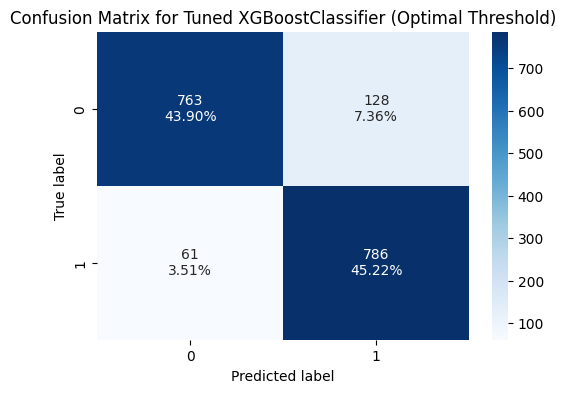

In [ ]:

# Generate the confusion matrix using y_test and y_pred_optimal
conf_matrix_xgb_optimal = confusion_matrix(y_test, y_pred_optimal)

# Plot the confusion matrix using the predefined function
plot_confusion_matrix_from_array(conf_matrix_xgb_optimal, "Confusion Matrix for Tuned XGBoostClassifier (Optimal Threshold)")

This confusion matrix, achieved with the optimal threshold of 0.52, indicates a strong model for predicting customer subscriptions. The high number of True Positives and relatively low False Negatives suggest that the model is excellent at identifying genuine interest in term deposits, ensuring that most potential subscribers are reached. The False Positives represent a manageable level of misdirection, a trade-off accepted to maximize the identification of actual subscribers. This balance is particularly desirable in marketing campaigns where maximizing outreach to interested customers is a primary goal, while still being mindful of efficiency.

### **Hyperparameters Explanation for Each Model:**

1.  **Logistic Regression**
    *   `max_iter`: This hyperparameter controls the maximum number of iterations taken for the solvers to converge. Logistic Regression uses an iterative optimization algorithm to find the best-fitting coefficients. If the solver doesn't converge within the specified `max_iter`, the algorithm stops, which might lead to suboptimal results or convergence warnings. Increasing this value can help the model converge, especially with complex datasets or when the default value is too small.

2.  **KNeighborsClassifier**
    *   `n_neighbors`: This is the most crucial hyperparameter for K-Nearest Neighbors. It defines the number of neighbors to consider when classifying a new data point. A smaller `n_neighbors` (e.g., 1 or 2) makes the model more sensitive to noise (high variance, low bias), while a larger `n_neighbors` (e.g., 5 or more) makes it smoother and more resistant to noise (low variance, high bias). The optimal value depends on the dataset.

3.  **DecisionTreeClassifier**
    *   `max_depth`: This hyperparameter controls the maximum depth of the decision tree. It limits how many splits the tree can make. A smaller `max_depth` prevents overfitting by simplifying the tree, making it less likely to capture noise in the training data (higher bias, lower variance). A deeper tree can capture more complex patterns but is prone to overfitting (lower bias, higher variance).

4.  **RandomForestClassifier**
    *   `n_estimators`: This hyperparameter specifies the number of individual decision trees (estimators) in the random forest. A random forest is an ensemble method, meaning it combines multiple decision trees to make a more robust prediction. Generally, a higher number of estimators leads to better performance and more stable predictions, but it also increases computation time. There's often a point of diminishing returns where adding more trees doesn't significantly improve performance.

5.  **XGBClassifier**
    *   `n_estimators`: Similar to RandomForestClassifier, this is the number of boosting rounds or trees to build. XGBoost builds trees sequentially, and each new tree corrects the errors of the previous ones. More estimators generally mean a more robust model, but too many can lead to overfitting.
    *   `subsample`: This controls the fraction of samples (observations) to be randomly sampled for each tree. Setting it to a value less than 1.0 (e.g., 0.8) means that the model will randomly sample 80% of the training data to build each tree. This technique, called subsampling or bagging, helps to reduce overfitting and adds diversity to the ensemble.